Importing Libraries

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms
from torchvision import datasets

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [5]:
transform = transforms.Compose([
    transforms.Resize((224,224)),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std = [0.229, 0.224, 0.225]
    )
])

Loading Dataset

In [6]:
train_dataset = datasets.Flowers102(
    root  = './data',
    split = 'train',
    download = True,
    transform = transform
)

val_dataset = datasets.Flowers102(
    root  = './data',
    split = 'val',
    download = True,
    transform = transform
)

test_dataset = datasets.Flowers102(
    root  = './data',
    split = 'test',
    download = True,
    transform = transform
)

In [7]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

1020
1020
6149


In [8]:
train_loader = DataLoader(
    train_dataset,
    batch_size = 32,
    shuffle = True
)

val_loader = DataLoader(
    val_dataset,
    batch_size = 32,
    shuffle = False
)

test_loader = DataLoader(
    test_dataset,
    batch_size = 32,
    shuffle = False
)

In [9]:
images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


Feature Extraction

In [10]:
from torchvision.models import vit_b_16, ViT_B_16_Weights

In [11]:
weights = ViT_B_16_Weights.DEFAULT
model = vit_b_16(weights= weights)

In [12]:
print(model)

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

Freezing Backbone Layers

In [13]:
for param in model.parameters():
    param.requires_grad = False

In [14]:
num_features = model.heads.head.in_features
model.heads.head = nn.Linear(num_features, 102)

In [15]:
model = model.to(device)

In [16]:
print(model.heads.head)

Linear(in_features=768, out_features=102, bias=True)


In [17]:
criterion = nn.CrossEntropyLoss()

In [18]:
optimizer = torch.optim.Adam(
    model.heads.head.parameters(),
    lr = 0.001
)

epochs = 10

In [19]:
train_losses = []
val_losses =[]

train_accuracies = []
val_accuracies = []

for epoch in range(epochs):
    model.train()

    running_loss = 0
    correct = 0
    total =0

    for images,labels in train_loader:
        images = images.to(device)
        labels= labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted==labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_accuracy = 100* correct/total

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)


    model.eval()

    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images.labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted==labels).sum().item()

    val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * correct/total

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Train Accuracy: {train_accuracy:.2f} | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Accuracy: {val_accuracy:.2f} | "
          f"Val Loss: {val_loss:.4f}"
    )

Epoch [1/10] | Train Accuracy: 15.78 | Train Loss: 4.1708 | Val Accuracy: 46.43 | Val Loss: 3.3390
Epoch [2/10] | Train Accuracy: 73.24 | Train Loss: 2.4297 | Val Accuracy: 89.29 | Val Loss: 1.9317
Epoch [3/10] | Train Accuracy: 88.53 | Train Loss: 1.4665 | Val Accuracy: 100.00 | Val Loss: 1.1123
Epoch [4/10] | Train Accuracy: 95.20 | Train Loss: 0.9600 | Val Accuracy: 100.00 | Val Loss: 0.6589
Epoch [5/10] | Train Accuracy: 96.67 | Train Loss: 0.6739 | Val Accuracy: 100.00 | Val Loss: 0.6102
Epoch [6/10] | Train Accuracy: 98.82 | Train Loss: 0.4967 | Val Accuracy: 100.00 | Val Loss: 0.3155
Epoch [7/10] | Train Accuracy: 99.02 | Train Loss: 0.3793 | Val Accuracy: 100.00 | Val Loss: 0.2888
Epoch [8/10] | Train Accuracy: 99.41 | Train Loss: 0.3023 | Val Accuracy: 100.00 | Val Loss: 0.2679
Epoch [9/10] | Train Accuracy: 99.61 | Train Loss: 0.2403 | Val Accuracy: 100.00 | Val Loss: 0.1510
Epoch [10/10] | Train Accuracy: 99.80 | Train Loss: 0.1974 | Val Accuracy: 100.00 | Val Loss: 0.2017


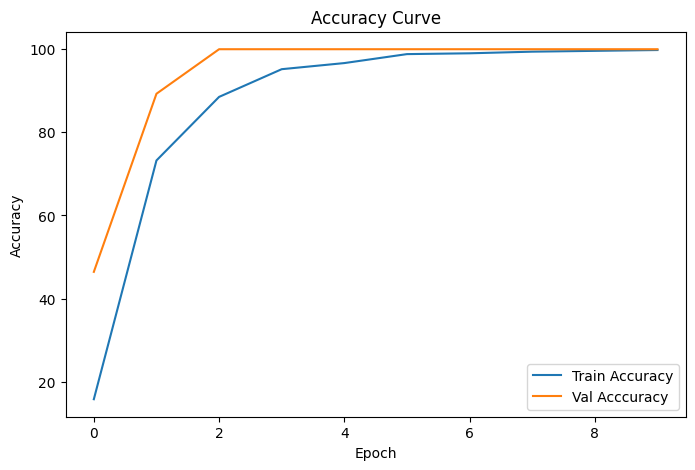

In [20]:
plt.figure(figsize=(8,5))

plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(val_accuracies, label="Val Acccuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")

plt.legend()
plt.show()

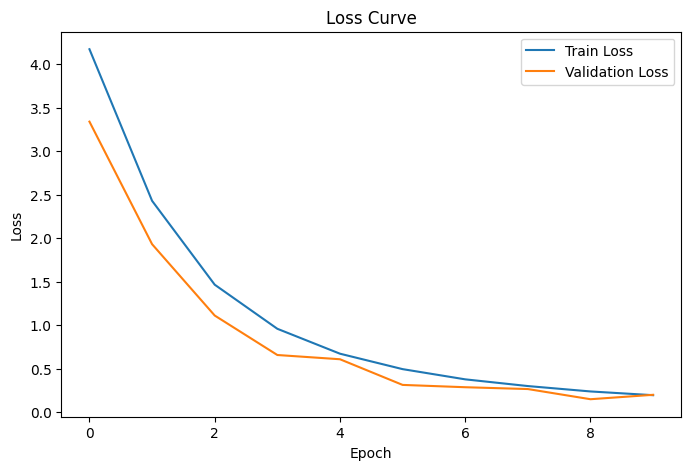

In [21]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")

plt.legend()
plt.show()

In [22]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy3 = 100 * correct / total

print("Test Accuracy:", test_accuracy3)

Test Accuracy: 82.63132216620589


In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_preds= []
all_labels= []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predicted = torch.max(outputs,1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

In [24]:
cm= confusion_matrix(all_labels, all_preds)

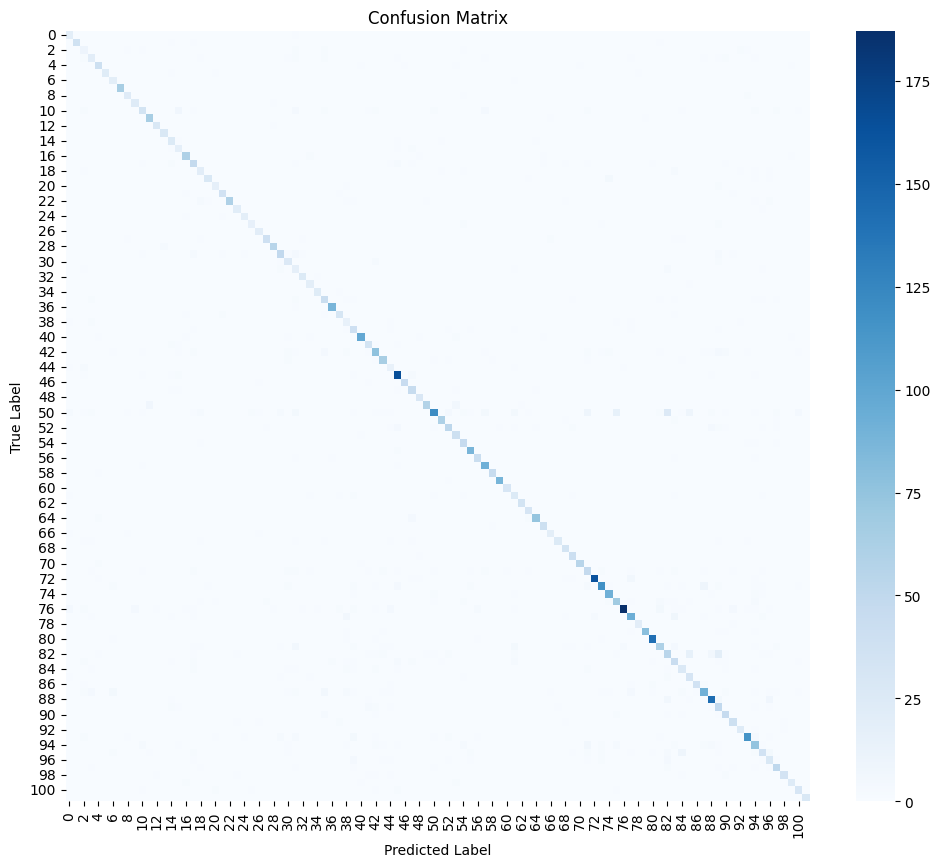

In [25]:
plt.figure(figsize=(12,10))

sns.heatmap(cm, cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds, digits=4))

Fine Tuning

In [26]:
from torchvision.models import vit_b_16, ViT_B_16_Weights

weights = ViT_B_16_Weights.DEFAULT
model2 = vit_b_16(weights = weights)

In [27]:
for param in model2.parameters():
    param.requires_grad = False

In [28]:
num_features = model2.heads.head.in_features
model2.heads.head = nn.Linear(num_features, 102)

In [29]:
print(model2)

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate='none')
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_a

Unfreezing Transformer Encoder

In [30]:
for param in model2.encoder.parameters():
    param.requires_grad= True

In [31]:
model2 = model2.to(device)

In [32]:
criterion2 = nn.CrossEntropyLoss()

In [33]:
optimizer2 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model2.parameters()),
    lr = 0.0001
)

epochs2 = 5

In [34]:
train_losses2 = []
val_losses2 = []

train_accuracies2 = []
val_accuracies2 = []

for epoch in range(epochs2):

    model2.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer2.zero_grad()

        outputs = model2(images)

        loss = criterion2(outputs, labels)

        loss.backward()

        optimizer2.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()


    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total

    train_losses2.append(train_loss)
    train_accuracies2.append(train_accuracy)



    model2.eval()

    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model2(images)

            loss = criterion2(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()


    val_loss = val_loss / len(val_loader)
    val_accuracy = 100 * correct / total

    val_losses2.append(val_loss)
    val_accuracies2.append(val_accuracy)


    print(f"Epoch [{epoch+1}/{epochs2}] | "
          f"Train Loss: {train_loss:.4f} | "
          f"Val Loss: {val_loss:.4f} | "
          f"Train Acc: {train_accuracy:.2f}% | "
          f"Val Acc: {val_accuracy:.2f}%")

Epoch [1/5] | Train Loss: 3.9845 | Val Loss: 2.5915 | Train Acc: 22.84% | Val Acc: 66.18%
Epoch [2/5] | Train Loss: 1.4358 | Val Loss: 1.2731 | Train Acc: 92.25% | Val Acc: 89.31%
Epoch [3/5] | Train Loss: 0.3443 | Val Loss: 0.7579 | Train Acc: 99.71% | Val Acc: 92.84%
Epoch [4/5] | Train Loss: 0.0897 | Val Loss: 0.6051 | Train Acc: 100.00% | Val Acc: 93.43%
Epoch [5/5] | Train Loss: 0.0428 | Val Loss: 0.5404 | Train Acc: 100.00% | Val Acc: 93.82%


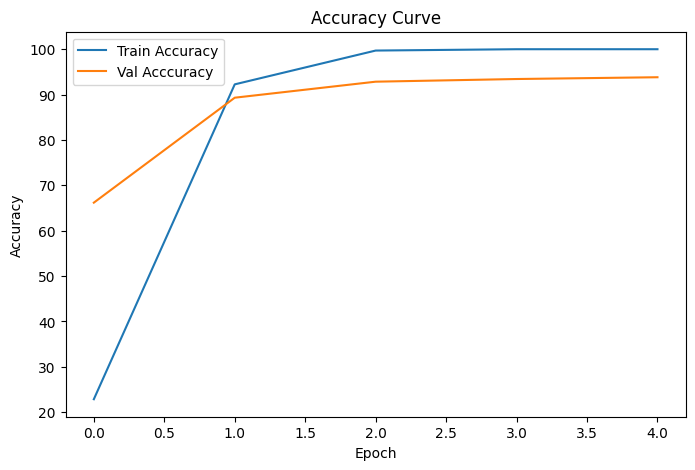

In [36]:
plt.figure(figsize=(8,5))

plt.plot(train_accuracies2, label="Train Accuracy")
plt.plot(val_accuracies2, label="Val Acccuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")

plt.legend()
plt.show()

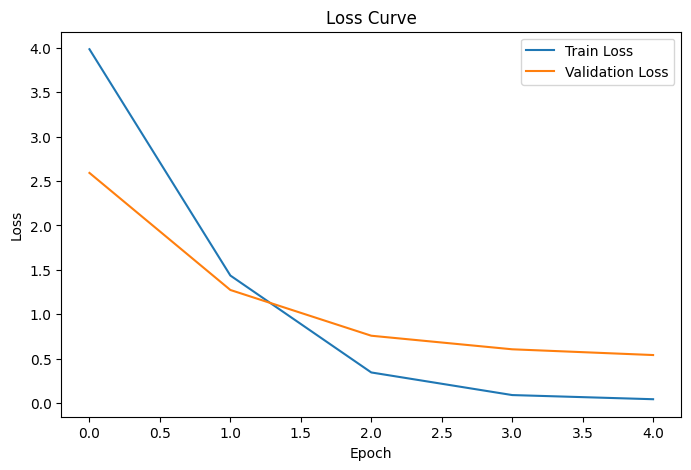

In [37]:
plt.figure(figsize=(8,5))

plt.plot(train_losses2, label="Train Loss")
plt.plot(val_losses2, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")

plt.legend()
plt.show()

In [35]:
model2.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model2(images)

        _, predicted = torch.max(outputs,1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print("Test Accuracy:", test_accuracy)

Test Accuracy: 91.64091722231257


In [38]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_preds= []
all_labels= []

model2.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model2(images)

        _, predicted = torch.max(outputs,1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

In [39]:
cm= confusion_matrix(all_labels, all_preds)

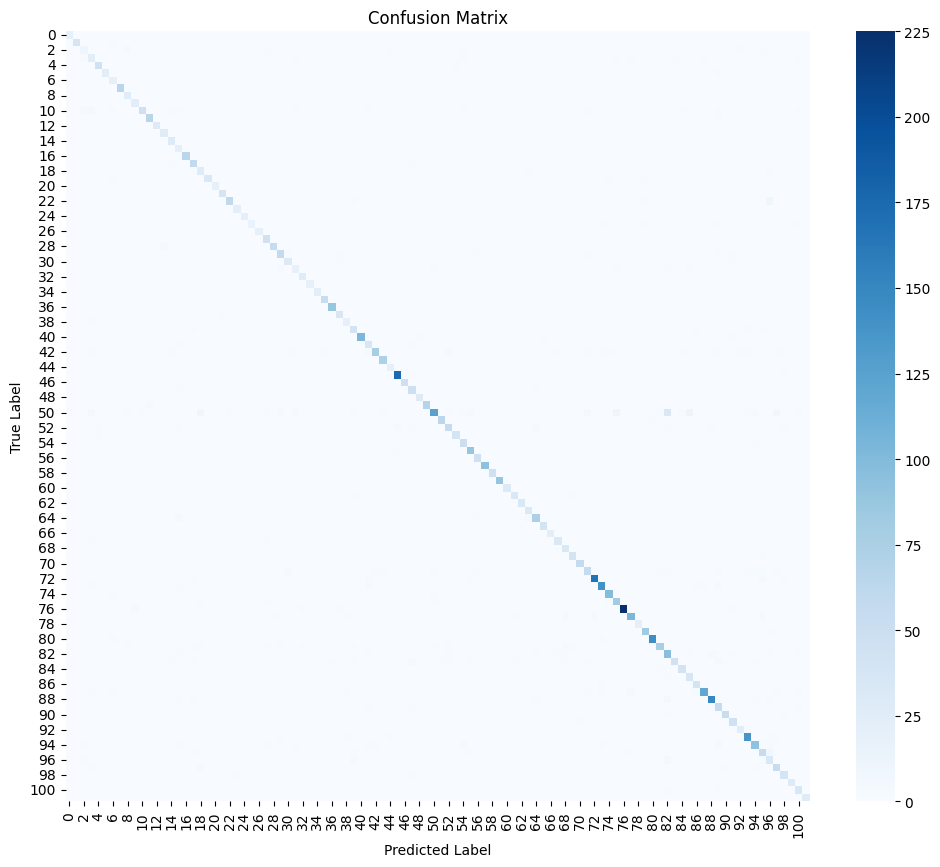

In [40]:
plt.figure(figsize=(12,10))

sns.heatmap(cm, cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(all_labels, all_preds, digits=4))